# Part B. Python/OpenCV Practice:
- Install Anaconda on your computer and use Jupyter Notebook as your
programming environment. Make sure that Python, OpenCV, NumPy and
Matplotlib are available.
- Download at least two grayscale images from the Internet, or use your own
grayscale images, then complete the following tasks.
## Task B1: Image reading, resizing, histogram equalization
Read the downloaded images using OpenCV. If an image is a color image,
convert it to grayscale. Then perform the following tasks:
(a) Histogram and histogram equalization:

- Compute and display the histogram of the grayscale image.
- Apply histogram equalization to the grayscale image.
- Compute and display the histogram of the equalized image.

(b) Resize the grayscale image to 150% of its original width and height.

(c) Display the following results:

- original image;
- grayscale image;
- resized grayscale image;
- histogram of the grayscale image;
- equalized grayscale image;
- histogram of the equalized grayscale image;
- grayscale image and equalized grayscale image side by side for comparison.

(d) Print the basic information of both the original image and the grayscale image, including:
- image size;
- number of channels;
- data type;
- minimum pixel value;
- maximum pixel value.

Start gray...
Finish gray...
Saved gray


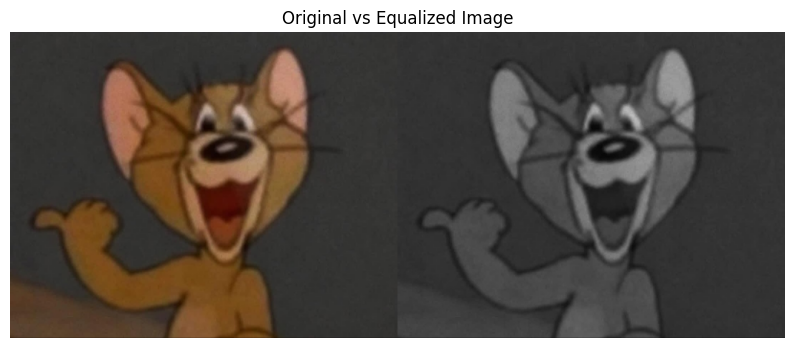

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("jerry.jpg")
#Turn image into grayscale
print("Start gray...")
for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        pixel = image[i][j]
        gray = int(int(pixel[0]) + int(pixel[1]) + int(pixel[2])) / 3
        pixel[0] = pixel[1] = pixel[2] = gray
print("Finish gray...")

cv2.imwrite("gray.jpg", image)
print("Saved gray")

original = cv2.imread("jerry.jpg")
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

res = np.hstack((original, image))
plt.figure(figsize=(10, 5))
plt.imshow(res, cmap='gray')  
plt.title("Original vs Equalized Image")
plt.axis('off')  
plt.show()

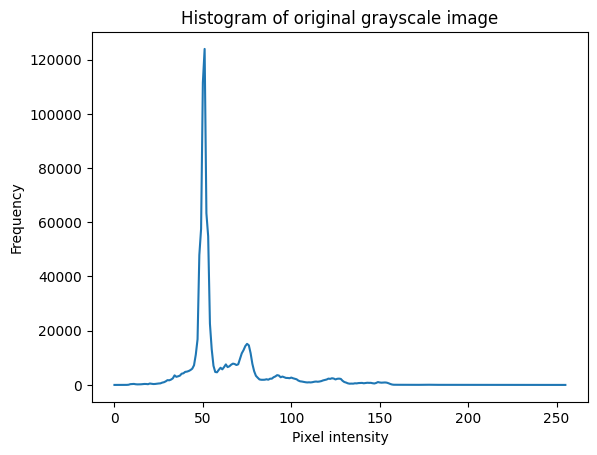

In [34]:
histg = cv2.calcHist([image], [0], None, [256], [0, 256])
plt.plot(histg)
plt.title("Histogram of original grayscale image")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.show()

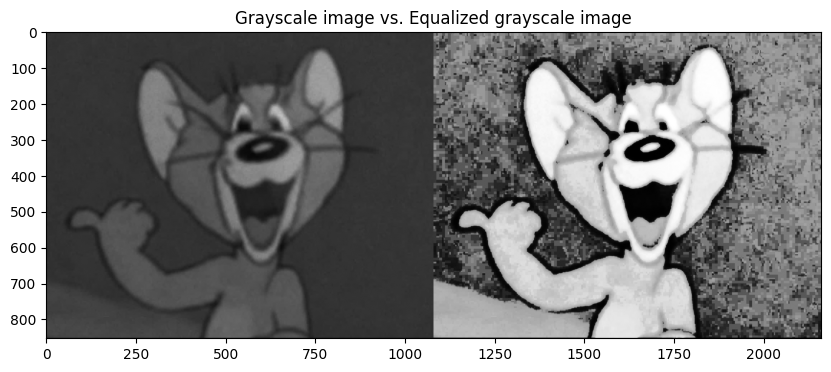

In [52]:
gray_img = cv2.imread("jerry.jpg", 0)
equa = cv2.equalizeHist(gray_img)
res = np.hstack((gray_img, equa))
plt.figure(figsize=(10,5))
plt.title("Grayscale image vs. Equalized grayscale image")
plt.imshow(res, cmap="gray")
#plt.axis("off")
plt.show()

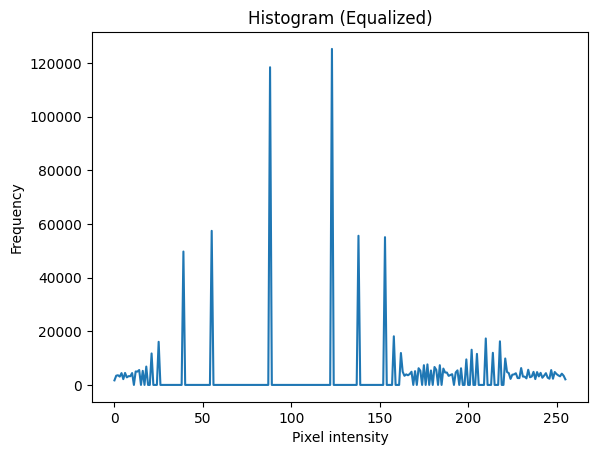

In [33]:
histg = cv2.calcHist([equa], [0], None, [256], [0, 256])
plt.plot(histg)
plt.title("Histogram (Equalized)")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.show()

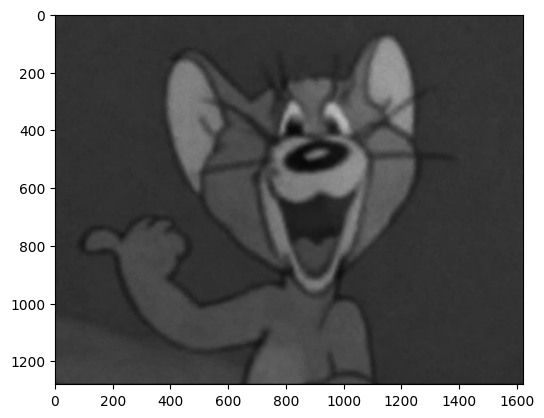

In [51]:
resized = cv2.resize(image, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)
plt.imshow(resized)

In [46]:
print("Width:", image.shape[0])
print("Length:", image.shape[1])
print("Number of channels:", image.shape[2])
print("Type:", type(image))

Width: 853
Length: 1080
Number of channels: 3
Type: <class 'numpy.ndarray'>


In [59]:
def findMaxMinPixel(image):
    max = min = image[0][0][0]
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            pixel = image[i][j]
            if pixel[0] > max:
                max = pixel[0]
            elif pixel[0] < min:
                min = pixel[0]
    res = [max, min]
    return res

print("Grayscale max pixel value:", findMaxMinPixel(image)[0])
print("Grayscale min pixel value:", findMaxMinPixel(image)[1])

Grayscale max pixel value: 192
Grayscale min pixel value: 6
